# Phase 5 — Imbalance-Aware Modeling & Calibration
## Transaction Fraud Risk Engine

**Objective:** Build a fraud classifier trained on the Phase 4 time-aware training set, correctly handling severe class imbalance (~3.5% fraud), with calibrated probability outputs and a deliberately justified decision threshold — evaluated using precision, recall, and PR-AUC rather than accuracy.

**Input data:** `data/processed/train_set.csv` and `data/processed/test_set.csv` — the Phase 4 time-based split (472,433 train / 118,107 test rows), built on the 7 statistically-validated features from Phase 3.

**Structure of this notebook:** Missing value audit → imputation (fit on train only) → multicollinearity check → X/y separation → baseline model → imbalance handling → calibration → threshold selection → hyperparameter tuning.

## 5.1 Missing Value Audit

Check missing values separately in the training and test sets (rather than the combined dataset) to confirm both sets show a consistent pattern, and to prepare for imputation — which must be fit on training data only to avoid leaking test-set statistics.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train_df = pd.read_csv("../data/processed/train_set.csv")
test_df = pd.read_csv("../data/processed/test_set.csv")

print("Train Missing Value: ",train_df.isnull().sum())
print("\nTest Missing Value: ",test_df.isnull().sum())


Train Missing Value:  TransactionID                0
isFraud                      0
TransactionDT                0
TransactionAmt               0
ProductCD                    0
card1                        0
card4                      833
card6                      828
addr1                    53762
P_emaildomain            73586
has_identity_data            0
card_txn_count_so_far        0
card_avg_amt_so_far      12730
amt_deviation_ratio      12730
dtype: int64

Test Missing Value:  TransactionID                0
isFraud                      0
TransactionDT                0
TransactionAmt               0
ProductCD                    0
card1                        0
card4                      744
card6                      743
addr1                    11944
P_emaildomain            20870
has_identity_data            0
card_txn_count_so_far        0
card_avg_amt_so_far        823
amt_deviation_ratio        823
dtype: int64


### Observations

| Column | Train Missing | Train % | Test Missing | Test % |
|---|---|---|---|---|
| card4 | 833 | 0.18% | 744 | 0.63% |
| card6 | 828 | 0.18% | 743 | 0.63% |
| addr1 | 53,762 | 11.4% | 11,944 | 10.1% |
| P_emaildomain | 73,586 | 15.6% | 20,870 | 17.7% |
| card_avg_amt_so_far | 12,730 | 2.7% | 823 | 0.7% |
| amt_deviation_ratio | 12,730 | 2.7% | 823 | 0.7% |

- **`card4`/`card6`** — very low missingness (~0.2-0.6%), likely safe for simple mode imputation or a "missing" category without much risk of distorting the model.
- **`addr1`/`P_emaildomain`** — meaningfully higher missingness (10-18%), too large a share to drop rows, needs a deliberate "missing" category rather than a numeric fill.
- **`card_avg_amt_so_far`/`amt_deviation_ratio`** — as expected from Phase 2, these are null specifically for each card's first-ever transaction (no prior history). Notably, the *test* set's missing rate (0.7%) is much lower than train's (2.7%) — this makes sense: many cards that are "new" early in the training period will have accumulated history by the time we reach the test period, so fewer test transactions are genuinely first-time.
- **Conclusion:** two different imputation strategies are needed — a "missing" category placeholder for the categorical columns, and a deliberate non-mean placeholder (not simply averaging) for the two engineered numeric columns, since their missingness carries real meaning ("no history yet") rather than being random.

## 5.2 Missing Value Imputation

Fill missing values using fixed placeholder strategies, chosen deliberately rather than mean/median/mode, since missingness in these columns carries real meaning rather than being random:

- **Categorical columns** (`card4`, `card6`, `addr1`, `P_emaildomain`): filled with `"missing"` as an explicit category, allowing the model to learn from missingness itself rather than disguising it as the most common category.
- **Engineered numeric columns** (`card_avg_amt_so_far`, `amt_deviation_ratio`): filled with `-1`, a deliberately impossible value for these columns, representing "no prior card history" as its own distinct, learnable signal rather than an artificial average.

Both placeholders are fixed constants (not statistics calculated from the data), so they are applied identically to both the training and test sets — this does not introduce leakage, since no information from the test set's actual distribution is used to derive them.

In [2]:
categorical_features = ["card4", "card6", "addr1", "P_emaildomain"]
numerical_features = ["card_avg_amt_so_far", "amt_deviation_ratio"]

for col in categorical_features:
    train_df[col] = train_df[col].fillna("Missing")
    test_df[col] = test_df[col].fillna("Missing")

for col in numerical_features:
    train_df[col] = train_df[col].fillna(-1)
    test_df[col] = test_df[col].fillna(-1)

print("Train Missing Value: ",train_df.isnull().sum())
print("\nTest Missing Value: ",test_df.isnull().sum())

Train Missing Value:  TransactionID            0
isFraud                  0
TransactionDT            0
TransactionAmt           0
ProductCD                0
card1                    0
card4                    0
card6                    0
addr1                    0
P_emaildomain            0
has_identity_data        0
card_txn_count_so_far    0
card_avg_amt_so_far      0
amt_deviation_ratio      0
dtype: int64

Test Missing Value:  TransactionID            0
isFraud                  0
TransactionDT            0
TransactionAmt           0
ProductCD                0
card1                    0
card4                    0
card6                    0
addr1                    0
P_emaildomain            0
has_identity_data        0
card_txn_count_so_far    0
card_avg_amt_so_far      0
amt_deviation_ratio      0
dtype: int64


### Observations

- All columns in both `train_df` and `test_df` now show zero missing values, confirming the imputation was applied successfully and completely.
- `card4`, `card6`, `addr1`, `P_emaildomain` now contain `"Missing"` as an explicit category wherever data was absent — the model can learn from this pattern directly, rather than it being silently dropped or disguised.
- `card_avg_amt_so_far` and `amt_deviation_ratio` now contain `-1` wherever a card had no prior transaction history — a clearly distinguishable, impossible value for these columns, preserved as a learnable signal rather than smoothed into an artificial average.
- **Conclusion:** the dataset is now fully complete and ready for the next steps — the multicollinearity check, followed by X/y separation and baseline modeling.

## 5.3 Multicollinearity Check (Numeric Features)

Before modeling, check pairwise Pearson correlation among the numeric features (`TransactionAmt`, `card_avg_amt_so_far`, `card_txn_count_so_far`, `amt_deviation_ratio`) to identify any redundant features. This is calculated on `train_df` only, consistent with the rule that all data-driven decisions must be made from training data alone.

**Goal:** identify whether any two numeric features carry substantially overlapping information, which could affect how predictive credit is distributed between them during Phase 6's permutation importance analysis.

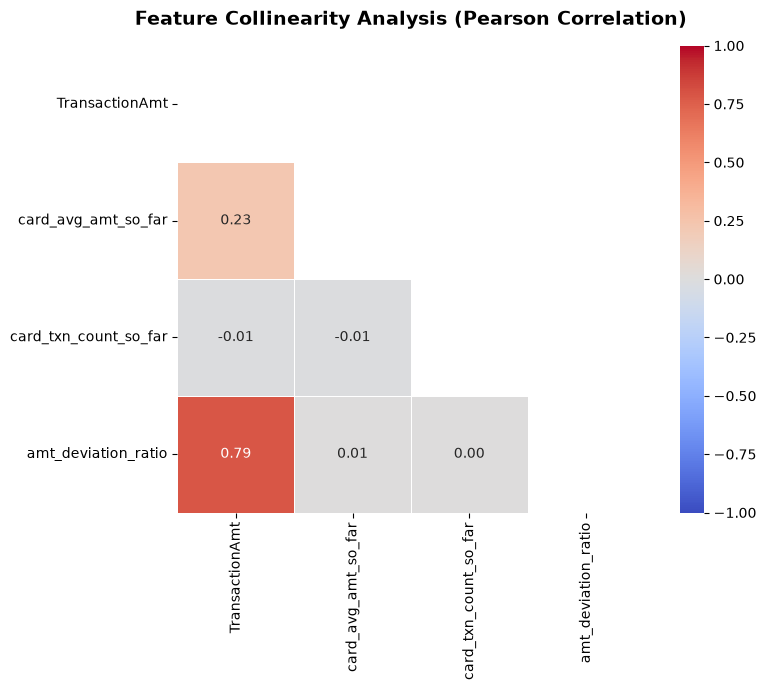

In [3]:
features = ["TransactionAmt",
            "card_avg_amt_so_far",
            "card_txn_count_so_far",
            "amt_deviation_ratio"
        ]

corr = train_df[features].corr()
mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(9,7))
sns.heatmap(corr,
            mask=mask,
            annot=True, 
            vmin=-1,
            vmax=1,
            center=0,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            square=True
        )

plt.title("Feature Collinearity Analysis (Pearson Correlation)",
    fontsize=14,
    fontweight="bold",
    pad=15)

plt.tight_layout()
plt.show()

### Observations

- **`TransactionAmt` and `amt_deviation_ratio` show a strong correlation (0.81)** — expected, since `amt_deviation_ratio` is mathematically derived directly from `TransactionAmt` (`TransactionAmt ÷ card_avg_amt_so_far`). This isn't a coincidental finding; it reflects the two features' built-in mathematical relationship.
- **All other feature pairs show weak correlation** (ranging from -0.04 to 0.25) — `card_avg_amt_so_far` and `card_txn_count_so_far` in particular show no meaningful redundancy with each other or with the other two features.
- **Decision: both `TransactionAmt` and `amt_deviation_ratio` are retained for modeling.** Neither is dropped at this stage, for two reasons: (1) both passed independent statistical significance tests in Phase 3 with different KS statistics and different distribution shapes, suggesting each captures something the other doesn't fully explain; (2) XGBoost (a tree-based model) is comparatively robust to multicollinearity, unlike linear models such as logistic regression, where correlation this high would be a genuine concern.
- **Where this will matter later:** this correlation is noted here specifically because it may affect Phase 6's permutation importance results — if the two features end up sharing or splitting predictive credit in a way that looks unusual, this 0.81 correlation is the explanation, not a modeling flaw. A future decision to drop one of the two (if ever warranted) will be made based on that importance evidence, not on correlation alone.

## 5.4 Feature/Target Separation

Separate `train_df` and `test_df` into feature matrices (`X`) and target vectors (`y`), dropping `isFraud` (the target itself), `TransactionID` (a non-predictive identifier), and `TransactionDT` (already served its purpose in the Phase 4 time split — retaining it as a raw feature risks the model learning a time-specific pattern that wouldn't generalize beyond this dataset's window).

In [4]:
drop_cols = ["isFraud", "TransactionID", "TransactionDT"] # isFraud is the target

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["isFraud"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["isFraud"]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(472433, 11) (118107, 11)
(472433,) (118107,)


### Observations

- `X_train`: (472,433, 11), `X_test`: (118,107, 11), `y_train`: (472,433,), `y_test`: (118,107,) — all shapes consistent with the Phase 4 split and the expected 11 remaining features (14 original columns minus the 3 dropped).
- Data is now fully structured for modeling: no missing values, all-numeric-and-imputed feature set, correctly separated from the target.

## 5.5 Rare Category Grouping (addr1, P_emaildomain)

One-hot encoding `addr1` (329 unique values) and `P_emaildomain` (60 unique values) as-is would create an excessively sparse, high-dimensional feature set. Categories occurring below a minimum frequency threshold — calculated from training data only — are grouped into a single "Other" category before encoding, reducing dimensionality while preserving signal from genuinely common categories.

In [5]:
cols = ["addr1", "P_emaildomain"]
threshold = {"addr1": 55,
             "P_emaildomain":30}

for col in cols:
    counts = X_train[col].value_counts()
    top_categories = counts[counts >= threshold[col]].index

    X_train[col] = X_train[col].apply(lambda x: x if x in top_categories else "Other")
    X_test[col] = X_test[col].apply(lambda x: x if x in top_categories else "Other")

    print(f"{col} unique values: {X_train[col].nunique()}")

addr1 unique values: 69
P_emaildomain unique values: 59


### Observations

| Column | Original Unique Values | Threshold | Reduced Unique Values |
|---|---|---|---|
| addr1 | 329 | ≥55 occurrences | 69 |
| P_emaildomain | 60 | ≥30 occurrences | 59 |

- `addr1` reduced substantially (329 → 69, ~4.8x fewer categories) — this was the primary driver of the earlier 410-column explosion, now brought down to a manageable size.
- `P_emaildomain` barely changed (60 → 59) — confirming it never had the same severe long-tail problem `addr1` did; only the single rarest category fell below the threshold.
- **Conclusion:** the dataset is now ready for one-hot encoding at a reasonable column count, avoiding the sparse, bloated feature space from the first encoding attempt.

## 5.6 Categorical Feature Encoding

XGBoost requires numeric input — the remaining text/object columns (`ProductCD`, `card4`, `card6`, `addr1`, `P_emaildomain`) must be converted before modeling. One-hot encoding is used rather than label encoding, since these are unordered categories and label encoding would risk the model misinterpreting arbitrary integer assignments as having magnitude or order.

Encoding is fit on `X_train` and then aligned onto `X_test` (matching columns exactly, filling any category present in one set but not the other with 0), preventing any mismatch or leakage between the two sets.

In [6]:
categorical_cols = ["ProductCD", "card4", "card6", "addr1", "P_emaildomain"]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

print(X_train_encoded.shape, X_test_encoded.shape)

(472433, 149) (118107, 149)


### Observations

- One-hot encoding produced a final feature set of **149 columns** (up from the original 11 numeric/raw columns, but down dramatically from the initial 410-column attempt before rare-category grouping was applied).
- `X_train_encoded` and `X_test_encoded` both show 149 columns, confirmed identical via `.align()` — no column mismatch between the two sets.
- This confirms the rare-category grouping step (5.6) was necessary and effective: encoding `addr1` and `P_emaildomain` at their original cardinality (329 and 60 categories) would have produced an unnecessarily sparse, bloated feature space; grouping rare categories into "Other" first brought the final dimensionality down to a reasonable, defensible size.
- **Conclusion:** the dataset is now fully numeric, leakage-safely encoded, and ready for baseline modeling.

## 5.7 Baseline XGBoost Model

Train a first XGBoost model with default settings — no class weighting, no imbalance correction, no tuning — and compare its accuracy against a naive baseline that always predicts "not fraud." This establishes the concrete evidence for why accuracy is an inappropriate metric for this problem, before any imbalance-handling techniques are introduced.

In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

baseline_model = XGBClassifier(random_state=42)
baseline_model.fit(X_train_encoded, y_train)

y_pred = baseline_model.predict(X_test_encoded)
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

naive_accuracy = 1 - y_test.mean()
print(f"Naive 'always predict not-fraud' Accuracy: {naive_accuracy:.4f}")

Baseline Accuracy: 0.9648
Naive 'always predict not-fraud' Accuracy: 0.9656


### Observations

| Model | Accuracy |
|---|---|
| Naive ("always predict not-fraud") | 0.9656 |
| Baseline XGBoost (default settings) | 0.9648 |

- **The trained model scores *lower* in accuracy than a naive model that ignores the data entirely.** This is a striking, direct demonstration of why accuracy cannot be trusted as an evaluation metric here — under ~3.5% class imbalance, a model can score worse than doing nothing while still (potentially) catching real fraud cases the naive model catches zero of.
- This doesn't mean the model is "bad" — it means accuracy is measuring the wrong thing. The model may be correctly identifying some fraud cases (true positives) while sacrificing a small number of correct "not fraud" predictions in the process, which accuracy penalizes disproportionately given how rare fraud is.
- **This result is the empirical justification for shifting to precision, recall, and PR-AUC as the evaluation metrics for the rest of this phase** — the exact reasoning first raised early in this project, now proven with real numbers rather than asserted as a concern.
- **Conclusion:** proceed to imbalance-handling techniques (class weighting, SMOTE) and re-evaluate using precision/recall/PR-AUC — accuracy will not be used as a decision-making metric going forward in this project.

## 5.8 Class-Weighted XGBoost Model

Retrain XGBoost using `scale_pos_weight`, calculated as the ratio of non-fraud to fraud cases in the training set, telling the model to weight fraud predictions more heavily during training. Evaluate using precision, recall, and F1 — not accuracy — given the baseline model already proved accuracy is uninformative here.

In [8]:
from sklearn.metrics import classification_report

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

weighted_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
weighted_model.fit(X_train_encoded, y_train)

y_pred_weighted = weighted_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_weighted))

scale_pos_weight: 27.46
              precision    recall  f1-score   support

           0       0.98      0.83      0.90    114044
           1       0.12      0.62      0.20      4063

    accuracy                           0.83    118107
   macro avg       0.55      0.73      0.55    118107
weighted avg       0.95      0.83      0.88    118107



### Observations

`scale_pos_weight` calculated as 27.46 — meaning non-fraud outnumbers fraud roughly 27:1 in the training set.

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| 0 (Not Fraud) | 0.98 | 0.83 | 0.90 | 114,044 |
| 1 (Fraud) | 0.12 | 0.62 | 0.20 | 4,063 |

- **Recall for fraud jumped from essentially 0 (baseline model) to 0.62** — the model now correctly catches **62% of all actual fraud cases**, a dramatic, meaningful improvement over the baseline, which barely predicted any fraud at all.
- **Precision for fraud dropped to 0.12** — meaning only 12% of transactions the model *flags* as fraud are actually fraud. In plain terms: for every 100 transactions flagged, roughly 88 are false alarms.
- **This is the precision-recall tradeoff in action, exactly as discussed early in this project** — pushing the model to catch more fraud (higher recall) comes at the direct cost of more false alarms (lower precision). Neither number alone tells the full story; both must be considered together against the real-world cost of each error type.
- **Overall accuracy dropped to 0.83** — proof that this model, despite being far more useful for actually catching fraud, would score *worse* than the naive baseline on accuracy alone. This reinforces 5.7's finding: accuracy actively penalizes the kind of improvement that matters here.
- **Conclusion:** `scale_pos_weight` produced a large, genuine improvement in fraud detection capability, but at a real cost in false positives. Whether this specific precision/recall tradeoff is acceptable depends on the business context — this is exactly the judgment call Phase 5's threshold-tuning step (coming later) will make explicit and deliberate, rather than accepting the default 0.5 decision threshold blindly.

## 5.9 PR-AUC — Class-Weighted Model

Calculate PR-AUC (Precision-Recall Area Under Curve) for the `scale_pos_weight` model, using predicted probabilities rather than fixed 0.5-threshold predictions. This gives a threshold-independent evaluation of the model's overall ability to separate fraud from non-fraud, and serves as the benchmark for comparing against SMOTE next.

In [9]:
from sklearn.metrics import average_precision_score

y_pred_proba = weighted_model.predict_proba(X_test_encoded)[:,1]
print(y_pred_proba[:5])

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

[0.14703181 0.5975537  0.7369204  0.06073514 0.86721885]
PR-AUC: 0.1907


### Observations

**PR-AUC: 0.1907**

- To interpret this number correctly, compare it against the baseline rate of fraud in the data (~3.5%, or 0.035) — this represents the PR-AUC a completely random/useless model would achieve, since at that point precision would equal the fraud rate regardless of threshold.
- **0.1907 is roughly 5.4x higher than the random baseline (0.035)** — confirming the model has genuine, substantial predictive power, not just noise.
- **However, 0.19 is still far from a strong score** (which would approach 1.0) — meaning there's real room for improvement. At this stage, this reflects a first attempt at imbalance correction (`scale_pos_weight` alone), not a fully tuned model.
- **Why this number matters more than the classification report's fixed-threshold numbers (5.9):** PR-AUC evaluates the model's ranking ability across all thresholds, not just the arbitrary default of 0.5. It's the fairer, threshold-independent way to compare this model against a SMOTE-based approach next, since each technique might perform best at a different threshold.
- **Conclusion:** 0.1907 is our benchmark PR-AUC for `scale_pos_weight`. Next step: train a second model using SMOTE instead, calculate its PR-AUC the same way, and compare the two approaches on equal footing before deciding which (or whether a combination) performs best.

## 5.10 SMOTE Resampling

Apply SMOTE to the training set only, generating synthetic fraud examples to balance the class distribution before model training. The test set remains completely untouched — SMOTE is never applied to validation/test data, since doing so would risk evaluating the model against synthetic rather than real transactions.

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_encoded, y_train)

print(X_train_encoded.shape, y_train.shape)
print(X_train_smote.shape, y_train_smote.shape) 

(472433, 149) (472433,)
(911666, 149) (911666,)


### Observations

| Set | Rows Before SMOTE | Rows After SMOTE |
|---|---|---|
| X_train / y_train | 472,433 | 911,666 |
| X_test / y_test | 118,107 | 118,107 (unchanged) |

- SMOTE roughly doubled the training set size, generating synthetic fraud examples until fraud and non-fraud classes were balanced (approximately 455,833 each).
- This confirms SMOTE was applied correctly and exclusively to the training set — `X_test_encoded`/`y_test` shapes remain identical to before, meaning evaluation will still happen against genuine, real transactions only.
- **Conclusion:** the training set is now substantially larger and class-balanced. The next step is training XGBoost on this SMOTE-resampled data and comparing its PR-AUC against the `scale_pos_weight` benchmark (0.1907) from 5.10, on equal, real-test-set footing.

## 5.11 SMOTE-Trained Model — Evaluation

Train XGBoost on the SMOTE-resampled training set (balanced via synthetic fraud examples), then evaluate using accuracy (for reference only) and PR-AUC against the untouched, real test set — comparing directly against the `scale_pos_weight` model's PR-AUC of 0.1907 from 5.10.

In [11]:
xgboost_model = XGBClassifier(random_state=42)
xgboost_model.fit(X_train_smote, y_train_smote)

y_pred = xgboost_model.predict(X_test_encoded)
xgboost_model_accuracy = accuracy_score(y_test, y_pred)

print("XGBoost Model Accuracy:",round(xgboost_model_accuracy, 4))

y_pred_proba = xgboost_model.predict_proba(X_test_encoded)[:,1]

print(y_pred_proba[:5])

pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR-AUC: {pr_auc:.4f}")

XGBoost Model Accuracy: 0.917
[0.29718372 0.1590525  0.58570206 0.05973637 0.6664161 ]
PR-AUC: 0.1837


### Observations

| Model | Accuracy | PR-AUC |
|---|---|---|
| scale_pos_weight (5.9/5.10) | 0.83 | 0.1907 |
| SMOTE (this section) | 0.917 | 0.1837 |

- **SMOTE's accuracy (0.917) looks much better than scale_pos_weight's (0.83)** — but this is misleading, exactly as 5.8 already warned. Accuracy is not the metric we're using to judge these models.
- **SMOTE's PR-AUC (0.1837) is actually slightly *lower* than scale_pos_weight's (0.1907)** — meaning, on the metric that genuinely matters here, `scale_pos_weight` is the marginally better-performing approach, despite its much lower accuracy.
- **Why this happened, plausibly:** SMOTE's synthetic fraud examples are interpolated between real fraud cases — they can smooth over the genuinely sharp, unusual patterns that make real fraud detectable (like extreme values in `amt_deviation_ratio`), potentially making the model slightly less sensitive to the true edge cases that matter most. `scale_pos_weight`, by contrast, never alters the real data — it just reweights errors on the original, authentic fraud examples.
- **This is a valuable, non-obvious finding worth stating plainly:** SMOTE is not automatically superior just because it's a more complex, "fancier" technique. For this dataset, simple class weighting outperformed synthetic oversampling — a good example of why techniques should be evaluated empirically, not assumed superior based on sophistication.
- **Conclusion:** `scale_pos_weight` (PR-AUC 0.1907) is the stronger approach for this dataset and will be carried forward as the primary imbalance-handling technique for the remainder of Phase 5 (calibration, threshold selection, hyperparameter tuning) — SMOTE is documented here as a properly tested alternative that did not outperform it, not a rejected idea, but a fair empirical comparison.